In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("car_data.csv")

data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
print("Minimum Manufacturing Year:", data['Year'].min())
print("Maximum Manufacturing Year:", data['Year'].max())

Minimum Manufacturing Year: 2003
Maximum Manufacturing Year: 2018


In [9]:
print("Lowest Selling Price:", data['Selling_Price'].min(), "lakh")

Lowest Selling Price: 0.1 lakh


In [10]:
print("Highest Selling Price:", data['Selling_Price'].max(), "lakh")

Highest Selling Price: 35.0 lakh


In [11]:
print("Number of records:", data.shape[0])

Number of records: 301


In [12]:
print(data.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [13]:
print("Number of different vehicles:", data['Car_Name'].nunique())

Number of different vehicles: 98


In [14]:
vehicle_count = data['Car_Name'].value_counts()

print(vehicle_count.head(10))

Car_Name
city                         26
corolla altis                16
verna                        14
fortuner                     11
brio                         10
ciaz                          9
i20                           9
innova                        9
grand i10                     8
Royal Enfield Classic 350     7
Name: count, dtype: int64


In [15]:
print(data['Fuel_Type'].value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


In [17]:
print(data['Seller_Type'].value_counts())

Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64


In [18]:
print(data['Transmission'].value_counts())

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [19]:
single_owner_count = (data['Owner'] == 1).sum()

print("Single-owner vehicles:", single_owner_count)

Single-owner vehicles: 10


In [20]:
data['Depreciation'] = data['Present_Price'] - data['Selling_Price']

data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Depreciation
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,2.24
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,4.79
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2.60
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,1.30
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,2.27


In [23]:
#most depreciated vehicle
data.loc[
    data['Depreciation'].idxmax(),
    ['Car_Name', 'Year', 'Present_Price', 'Selling_Price', 'Depreciation']
]

Car_Name         land cruiser
Year                     2010
Present_Price            92.6
Selling_Price            35.0
Depreciation             57.6
Name: 86, dtype: object

In [22]:
data.loc[
    data['Depreciation'].idxmin(),
    ['Car_Name', 'Year', 'Present_Price', 'Selling_Price', 'Depreciation']
]

Car_Name         Honda Activa 4G
Year                        2017
Present_Price               0.51
Selling_Price               0.48
Depreciation                0.03
Name: 155, dtype: object

In [24]:
data['Depreciation_Percentage'] = (
    (data['Present_Price'] - data['Selling_Price'])
    / data['Present_Price']
) * 100

In [25]:
least_depreciated = (
    data.groupby('Car_Name')['Depreciation_Percentage']
    .mean()
    .sort_values()
)

print(least_depreciated.head(10))

Car_Name
vitara brezza                5.900305
Bajaj Avenger 150            6.250000
UM Renegade Mojave           6.593407
TVS Sport                    7.692308
Yamaha FZ 16                 8.536585
Honda Activa 4G              8.823529
Hero Passion X pro           9.090909
Bajaj Dominar 400            9.375000
Royal Enfield Bullet 350    10.256410
Honda Dream Yuga            11.111111
Name: Depreciation_Percentage, dtype: float64


In [26]:
fuel_analysis = data.groupby('Fuel_Type').agg(
    Average_Depreciation=('Depreciation', 'mean'),
    Average_Depreciation_Percentage=('Depreciation_Percentage', 'mean')
)

print(fuel_analysis)

           Average_Depreciation  Average_Depreciation_Percentage
Fuel_Type                                                       
CNG                    3.315000                        49.017809
Diesel                 5.536000                        32.035459
Petrol                 2.319372                        37.585115


In [27]:
data['Vehicle_Age'] = data['Year'].max() - data['Year']

data[['Year', 'Vehicle_Age']].head()

,Year,Vehicle_Age
0,2014,4
1,2013,5
2,2017,1
3,2011,7
4,2014,4


In [28]:
age_correlation = data['Vehicle_Age'].corr(data['Selling_Price'])

print("Correlation between Vehicle Age and Selling Price:",
      age_correlation)

Correlation between Vehicle Age and Selling Price: -0.23614098016042734


In [29]:
kms_correlation = data['Kms_Driven'].corr(data['Selling_Price'])

print("Correlation between KMs Driven and Selling Price:",
      kms_correlation)

Correlation between KMs Driven and Selling Price: 0.029187090674291247


In [30]:
newest_vehicles = data[data['Year'] > 2014]

newest_vehicles

print("Vehicles manufactured after 2014:",
      len(newest_vehicles))

Vehicles manufactured after 2014: 147


In [31]:
bike_names = [
    'Activa 3g',
    'Activa 4g',
    'Bajaj  ct 100',
    'Bajaj Avenger 150',
    'Bajaj Avenger 150 street',
    'Bajaj Avenger 220',
    'Bajaj Avenger 220 dtsi',
    'Bajaj Avenger Street 220',
    'Bajaj Discover 100',
    'Bajaj Discover 125',
    'Bajaj Dominar 400',
    'Bajaj Pulsar  NS 200',
    'Bajaj Pulsar 135 LS',
    'Bajaj Pulsar 150',
    'Bajaj Pulsar 220 F',
    'Bajaj Pulsar NS 200',
    'Bajaj Pulsar RS200',
    'Hero  CBZ Xtreme',
    'Hero  Ignitor Disc',
    'Hero Extreme',
    'Hero Glamour',
    'Hero Honda CBZ extreme',
    'Hero Honda Passion Pro',
    'Hero Hunk',
    'Hero Passion Pro',
    'Hero Passion X pro',
    'Hero Splender iSmart',
    'Hero Splender Plus',
    'Hero Super Splendor',
    'Honda Activa 125',
    'Honda Activa 4G',
    'Honda CB Hornet 160R',
    'Honda CB Shine',
    'Honda CB Trigger',
    'Honda CB twister',
    'Honda CB Unicorn',
    'Honda CBR 150',
    'Honda Dream Yuga ',
    'Honda Karizma',
    'Hyosung GT250R',
    'KTM 390 Duke ',
    'KTM RC200',
    'KTM RC390',
    'Mahindra Mojo XT300',
    'Royal Enfield Bullet 350',
    'Royal Enfield Classic 350',
    'Royal Enfield Classic 500',
    'Royal Enfield Thunder 350',
    'Royal Enfield Thunder 500',
    'Suzuki Access 125',
    'TVS Apache RTR 160',
    'TVS Apache RTR 180',
    'TVS Jupyter',
    'TVS Sport ',
    'TVS Wego',
    'UM Renegade Mojave',
    'Yamaha FZ  v 2.0',
    'Yamaha FZ 16',
    'Yamaha FZ S ',
    'Yamaha FZ S V 2.0',
    'Yamaha Fazer '
]

bikes = data[data['Car_Name'].isin(bike_names)]

print("Number of two-wheeler records:", len(bikes))

Number of two-wheeler records: 101


In [32]:
oldest_bike_year = bikes['Year'].min()

print("Oldest bike year:", oldest_bike_year)

bikes[bikes['Year'] == oldest_bike_year]

newest_bike_year = bikes['Year'].max()

print("Newest bike year:", newest_bike_year)

bikes[bikes['Year'] == newest_bike_year][
    ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven']
]

Oldest bike year: 2005
Newest bike year: 2017


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven
101,UM Renegade Mojave,2017,1.70,1.82,1400
102,KTM RC200,2017,1.65,1.78,4000
103,Bajaj Dominar 400,2017,1.45,1.60,1200
104,Royal Enfield Classic 350,2017,1.35,1.47,4100
109,Royal Enfield Classic 350,2017,1.20,1.47,11000
126,Bajaj Avenger 220,2017,0.90,0.95,1300
128,Honda CB Hornet 160R,2017,0.80,0.87,3000
129,Yamaha FZ S V 2.0,2017,0.78,0.84,5000
130,Honda CB Hornet 160R,2017,0.75,0.87,11000
132,Bajaj Avenger 220,2017,0.75,0.95,3500


In [33]:
bike_count = bikes['Car_Name'].value_counts()

print(bike_count.head(10))

print("Most sold bike:", bike_count.idxmax())
print("Number of records:", bike_count.max())

Car_Name
Royal Enfield Classic 350    7
Royal Enfield Thunder 350    4
Bajaj Pulsar 150             4
Bajaj Avenger 220            3
Royal Enfield Thunder 500    3
Honda CB Hornet 160R         3
Yamaha FZ S V 2.0            3
TVS Apache RTR 160           3
Bajaj Pulsar NS 200          3
Hero Extreme                 2
Name: count, dtype: int64
Most sold bike: Royal Enfield Classic 350
Number of records: 7


In [34]:
bikes = bikes.copy()

bikes['Price_Retention_Percentage'] = (
    bikes['Selling_Price'] / bikes['Present_Price']
) * 100

bikes.sort_values(
    'Price_Retention_Percentage',
    ascending=False
)[[
    'Car_Name',
    'Year',
    'Selling_Price',
    'Present_Price',
    'Kms_Driven',
    'Price_Retention_Percentage'
]].head(10)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Price_Retention_Percentage
126,Bajaj Avenger 220,2017,0.90,0.95,1300,94.736842
155,Honda Activa 4G,2017,0.48,0.51,4300,94.117647
127,Bajaj Avenger 150,2016,0.75,0.80,7000,93.750000
101,UM Renegade Mojave,2017,1.70,1.82,1400,93.406593
129,Yamaha FZ S V 2.0,2017,0.78,0.84,5000,92.857143
102,KTM RC200,2017,1.65,1.78,4000,92.696629
156,TVS Sport,2017,0.48,0.52,15000,92.307692
100,Royal Enfield Thunder 500,2016,1.75,1.90,3000,92.105263
128,Honda CB Hornet 160R,2017,0.80,0.87,3000,91.954023
104,Royal Enfield Classic 350,2017,1.35,1.47,4100,91.836735


In [35]:
cars = data[~data['Car_Name'].isin(bike_names)].copy()

print("Number of car records:", len(cars))

Number of car records: 200


In [36]:
oldest_car_year = cars['Year'].min()

print("Oldest car year:", oldest_car_year)

cars[cars['Year'] == oldest_car_year][
    ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven']
]

Oldest car year: 2003


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven
37,800,2003,0.35,2.28,127000
39,sx4,2003,2.25,7.98,62000


In [37]:
newest_car_year = cars['Year'].max()

print("Newest car year:", newest_car_year)

cars[cars['Year'] == newest_car_year][
    ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven']
]

Newest car year: 2018


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven
5,vitara brezza,2018,9.25,9.83,2071


In [38]:
cars['Price_Retention_Percentage'] = (
    cars['Selling_Price'] / cars['Present_Price']
) * 100

cars.sort_values(
    'Price_Retention_Percentage',
    ascending=False
)[[
    'Car_Name',
    'Year',
    'Selling_Price',
    'Present_Price',
    'Kms_Driven',
    'Price_Retention_Percentage'
]].head(10)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Price_Retention_Percentage
80,corolla altis,2016,14.73,14.89,23000,98.925453
8,ciaz,2016,8.75,8.89,20273,98.425197
231,verna,2017,9.25,9.40,15001,98.404255
208,i20,2017,7.90,8.10,3435,97.530864
235,verna,2017,9.10,9.40,15141,96.808511
234,grand i10,2015,5.50,5.70,4492,96.491228
250,creta,2016,12.90,13.60,35934,94.852941
5,vitara brezza,2018,9.25,9.83,2071,94.099695
83,innova,2015,12.50,13.46,38000,92.867756
27,swift,2017,6.00,6.49,16200,92.449923


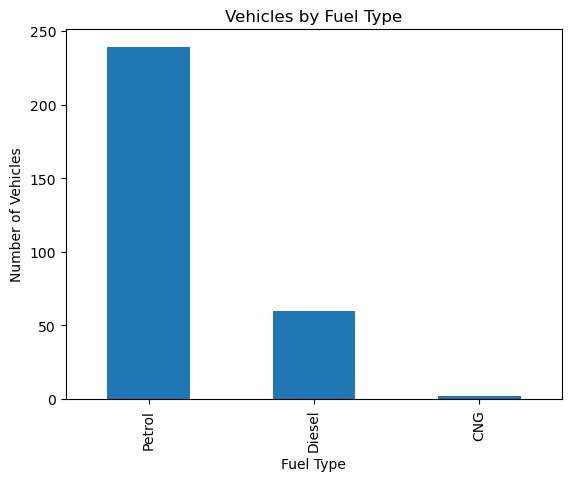

In [39]:
data['Fuel_Type'].value_counts().plot(kind='bar')

plt.title('Vehicles by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Vehicles')
plt.show()

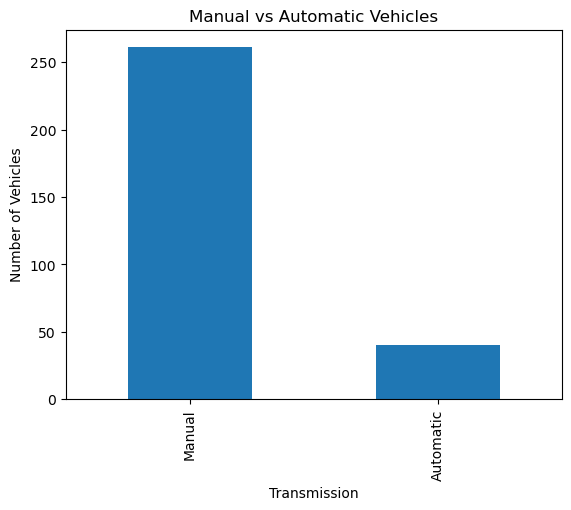

In [40]:
data['Transmission'].value_counts().plot(kind='bar')

plt.title('Manual vs Automatic Vehicles')
plt.xlabel('Transmission')
plt.ylabel('Number of Vehicles')
plt.show()

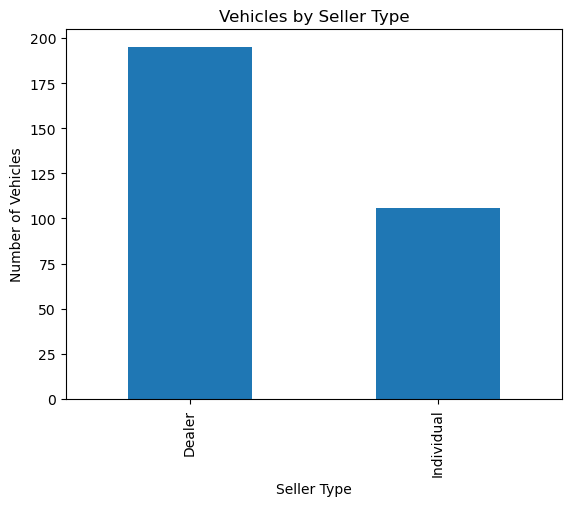

In [41]:
data['Seller_Type'].value_counts().plot(kind='bar')

plt.title('Vehicles by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Number of Vehicles')
plt.show()

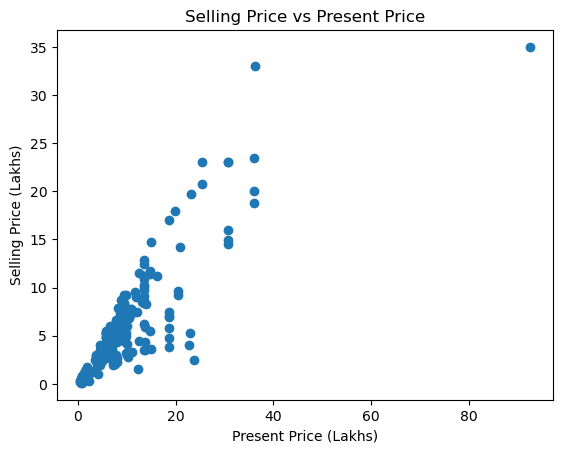

In [42]:
plt.scatter(data['Present_Price'], data['Selling_Price'])

plt.title('Selling Price vs Present Price')
plt.xlabel('Present Price (Lakhs)')
plt.ylabel('Selling Price (Lakhs)')
plt.show()

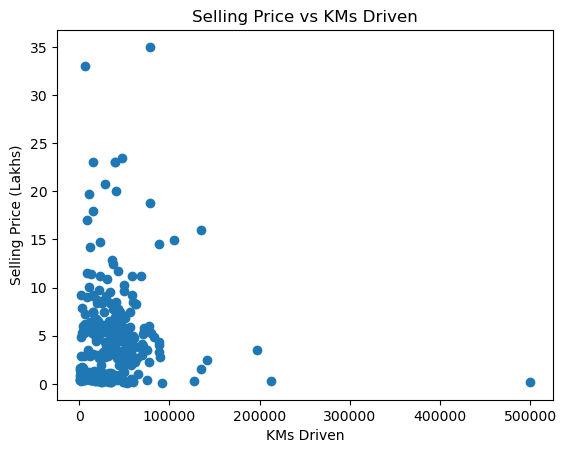

In [47]:
plt.scatter(data['Kms_Driven'], data['Selling_Price'])

plt.title('Selling Price vs KMs Driven')
plt.xlabel('KMs Driven')
plt.ylabel('Selling Price (Lakhs)')
plt.show()

In [48]:
import os

print(os.getcwd())

C:\Users\aakan\car_analysis
